In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.fit import *

from pmt.fit.poisson import fit_poisson_spe, poisson_npe_fractions
from pmt.fit.bellamy import fit_bellamy_spe


# from pmt.fit.pedestal_gaussian import fit_pedestal
# from pmt.fit.pedestal_bellamy import fit_pedestal_bellamy
from pmt.fit.pedestal_exponential_gaussian import fit_pedestal_expgauss

from pmt.fit.core import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
data_dir = Path("data/WA0089/LED_sweep/260625/850V_525MHz")

# file_name = "led_080"
file_name = "led_100"
# file_name = "led_120"

# Set to a number for quick iteration, or None to use all matching files.
max_files = None

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260625/850V_525MHz/led_100-1.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-10.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-2.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-3.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-4.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-5.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-6.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-7.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-8.h5
data/WA0089/LED_sweep/260625/850V_525MHz/led_100-9.h5
Number of files loaded: 10


### if and where to save plots

In [3]:
save_plots = False
# save_dir = 'plots_fit_results_850V_20MHz'
save_dir = '-'
file_nickname = file_name

# Configuration

In [4]:
# cfg = load_config("config_default.yml", file_name)
# print(cfg)

In [5]:
chunk_size = 512 #4096
baseline_window_width_ns          = 20
selection_peak_threshold_max_mV   = 0.5


In [6]:
max_sample_events = 2

sample = read_waveform_sample(files, max_events=max_sample_events, channel="Channel 2")
time_ns = sample["time_ns"]
adc_step_mV = sample["adc_step_mV"]

print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")
print(sample.keys())

baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

Time range: -10.016 to 89.984 ns
Sampling step: 0.01562 ns
ADC step: 0.000255 mV

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])


# Load Sample and compute charge


In [7]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    baseline_subtraction=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None,
    high_limit_mV=None,
    margin_mV=0.0,
    max_saturated_samples=0,
    channel="Channel 2"
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]
# baseline_mV = prerocessed_data["baseline_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}

prerocessed_data.keys()



TypeError: load_preprocessed_waveforms() got an unexpected keyword argument 'baseline_subtraction'

# Selection

In [ ]:
df =  build_waveform_feature_dataframe( time_ns, voltage_mV, extra=preprocessed_event_info)
# df

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


In [ ]:
# reject events with main peak inside the baseline window -> the baseline computation fails when the peak in inside
# optional: require the peak to be larger than a specific  value (e.g. 0.5mV) so that we don't thouw away pedestal events
sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
sanity_mask_keep = ~sanity_mask_reject
df_sel = df[sanity_mask_keep].copy()
waveforms_sel = voltage_mV[df_sel["event_id"].values]

### Charge Computation

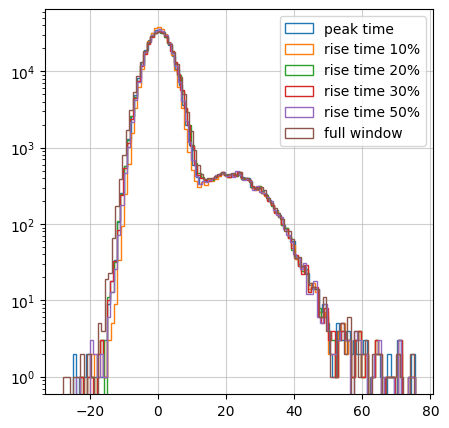

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

rg = None #(-20, 10)
den=False

axes.hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes.hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes.hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes.hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes.hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes.hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes.set_yscale('log');
axes.legend();




# Fit pedestal only

In [ ]:
pedestal_mask = ( df_sel.peak_amplitude_mV<=0.5) #LED 0

df_ped = df_sel[pedestal_mask].copy()
waveforms_ped = waveforms_sel[pedestal_mask.values]
print('pedestal selection efficiency: ', waveforms_ped.shape[0]/waveforms_sel.shape[0])

df_PEs = df_sel[~pedestal_mask].copy()
waveforms_PEs = waveforms_sel[~pedestal_mask.values]

pedestal selection efficiency:  0.0


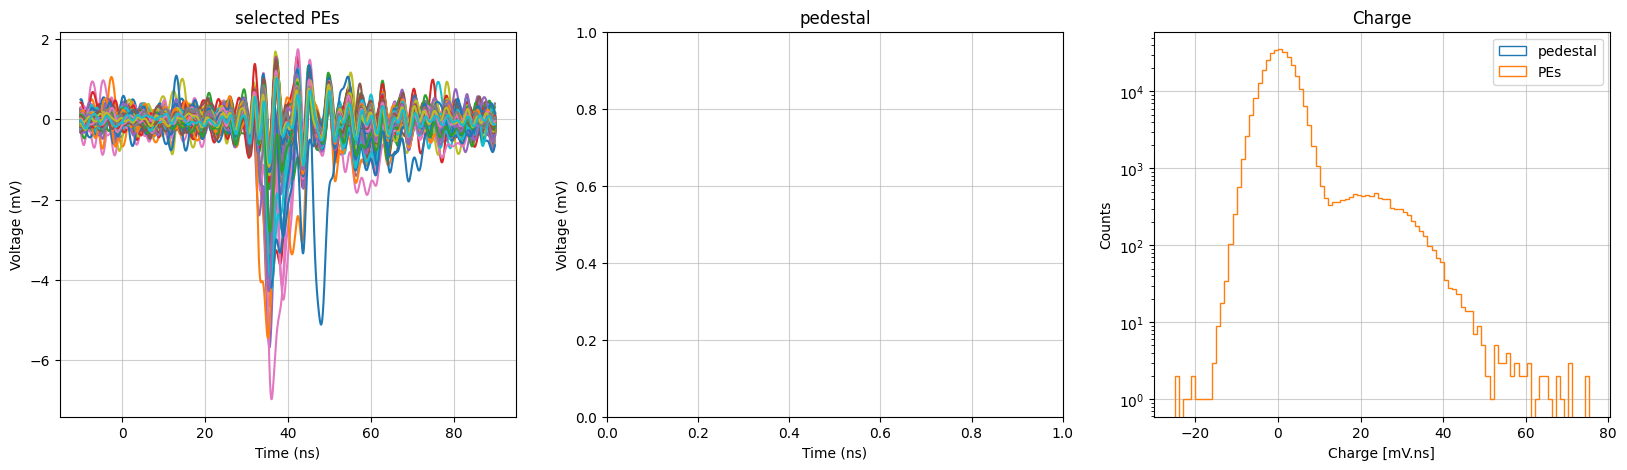

In [ ]:
nEvts_plot = 1000
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes = axes.ravel()
add_plot_waveforms(axes[0], time_ns, waveforms_PEs[:nEvts_plot], title=f"selected PEs")
add_plot_waveforms(axes[1], time_ns, waveforms_ped[:nEvts_plot], title=f"pedestal")
axes[2].hist(df_ped.charge_peak_window_mV_ns,  bins=100, range=rg, histtype='step', label="pedestal");
axes[2].hist(df_PEs.charge_peak_window_mV_ns,  bins=100, range=rg, histtype='step', label="PEs");
axes[2].set_title('Charge');
axes[2].set_xlabel('Charge [mV.ns]')
axes[2].set_ylabel('Counts')
axes[2].set_yscale('log')
axes[2].legend();


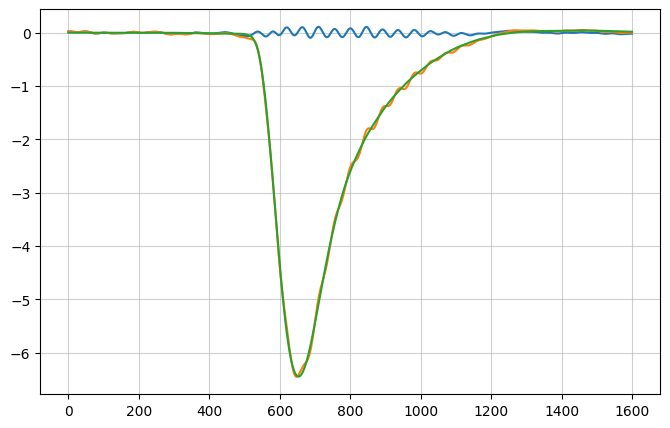

In [ ]:
mean_ped = np.mean( waveforms_ped, axis=0)
mean_PEs = np.mean( waveforms_PEs, axis=0)

plt.plot(mean_ped)
plt.plot(mean_PEs)
plt.plot(mean_PEs - mean_ped);

# Pedestal

In [ ]:
charge_ped_mV_ns = df_ped.charge_cfd20_window_mV_ns.values
fit_ped_range = (np.min(charge_ped_mV_ns), np.max(charge_ped_mV_ns))
nbins = 250
print(f'fit range = ({fit_ped_range[0]:.2f}, {fit_ped_range[1]:.2f}); {nbins} bins')


fit range = (-17.16, 16.06); 250 bins


### Exp.Gaussian

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total          56846.0000  56661.6307     238.0664    [28423.0, 113692.0]   False
q0_mV_ns             0.3000     -1.0201       0.0296           [-6.0, 10.0]   False
sigma0_mV_ns         2.5000      2.5185       0.0154            [0.0, 50.0]   False
alpha                0.3000      0.6900       0.0137            [0.0, 10.0]   False

[]


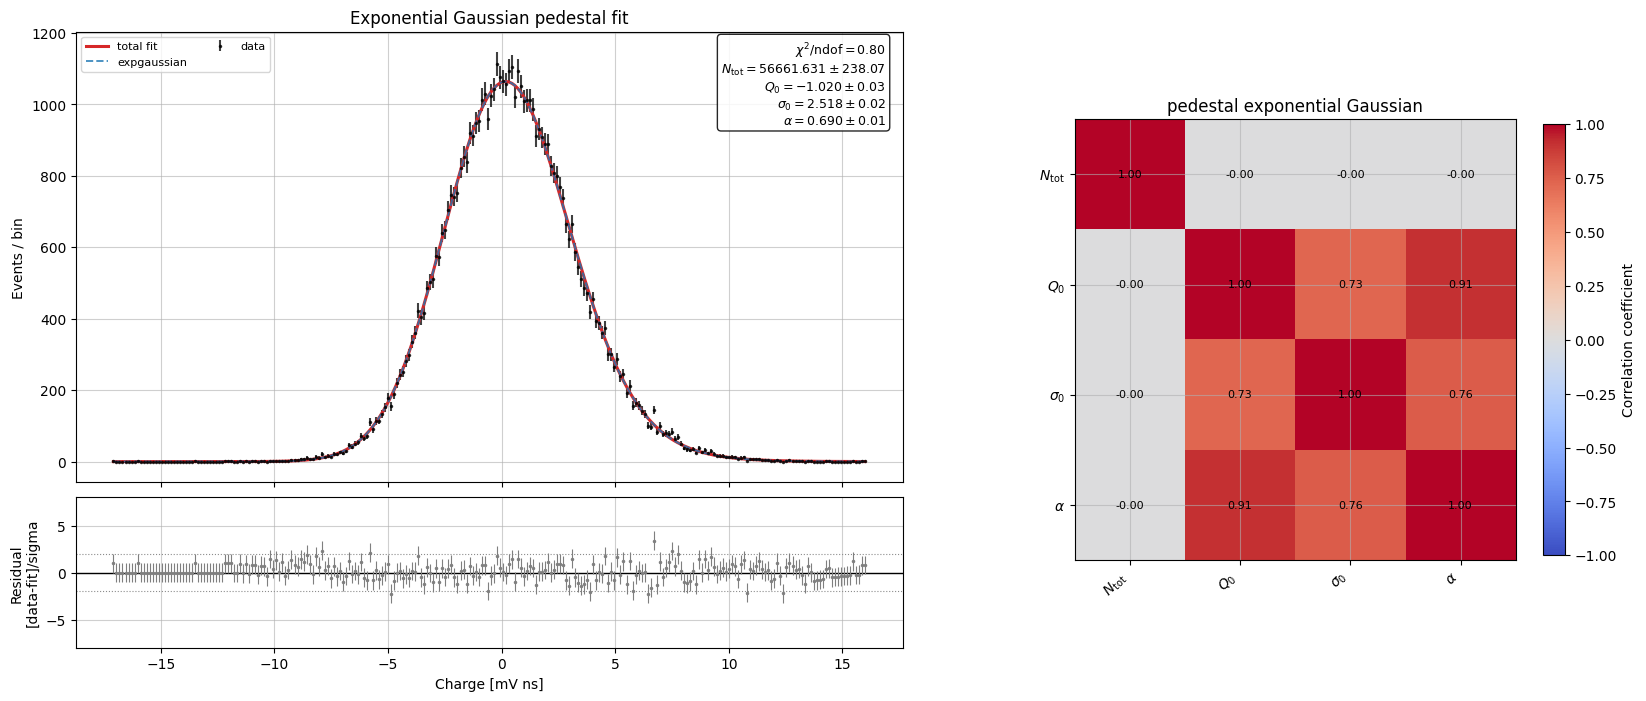

In [ ]:
p0_pedestal_expgauss = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_ped_mV_ns), 0.5 * len(charge_ped_mV_ns), 2.0 * len(charge_ped_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "alpha":        [0.3, 0., 10.,     False], # coeff. of the exponential decay of type 2-background (positive)
}
fit_ped_expgauss = fit_pedestal_expgauss( charge_ped_mV_ns, p0=p0_pedestal_expgauss, fit_range=fit_ped_range)
print_fit_result_table(fit_ped_expgauss)
print()
print(fit_ped_expgauss["diagnostics"])

fig, ax_fit, ax_resid, ax_corr = ( plot_fit_summary( fit_ped_expgauss, title="Exponential Gaussian pedestal fit", shrink_colorbar=0.7, component_visibility_fraction=0, logscale=False))
save_plot(fig, save_plots, save_dir, file_nickname, f"pedestal_fit_exGauss_{nbins}bins",  Nevents=None);

# Bellamy's fit

In [ ]:
charge_mV_ns = df_sel.charge_cfd20_window_mV_ns.values
fit_range = (np.min(charge_mV_ns), np.max(charge_mV_ns))
nbins = 250
print(f'fit range = ({fit_range[0]:.2f}, {fit_range[1]:.2f}); {nbins} bins')


fit range = (-68.43, 477.65); 250 bins


In [ ]:
def format_value(value, error, digits=1):
    """
    Format value ± error as (a ± b) × 10^n.
    """

    if value == 0:
        return f"0 ± {error:.{digits}g}"

    exponent = int(np.floor(np.log10(abs(value))))

    scale = 10**exponent

    mantissa = value / scale
    mantissa_err = error / scale

    return (
        f"({mantissa:.{digits}f} ± "
        f"{mantissa_err:.{digits}f}) × 10^{exponent}"
    )

Parameter           Initial         Fit       Error                Bounds   Fixed
---------------------------------------------------------------------------------
n_total         158374.0000 158503.9918     402.8481    [79187.0, 316748.0]   False
mu_pe                0.0300      0.9727       0.0033             [0.0, 5.0]   False
q0_mV_ns            -1.0201     -1.0201       0.0000           [-1.0, -1.0]    True
sigma0_mV_ns         2.5185      2.5185       0.0000             [2.5, 2.5]    True
q1_mV_ns            30.0000     62.2580       0.1255           [5.0, 100.0]   False
sigma1_mV_ns        11.0000     24.1772       0.0938            [5.0, 30.0]   False
w                    0.5000      0.6614       0.0075             [0.0, 1.0]   False
alpha                0.6900      0.3421       0.0044            [0.0, 10.0]   False

[]
Gain is 7.77e+06 +-1.57e+04 for Q1 = 62.257958025271506
(7.77 ± 0.02) × 10^6


[PosixPath('plots_fit_results/2steps/WA0089_850V_20MHz_Cold_led3_fit_Bellamy_250bins.pdf')]

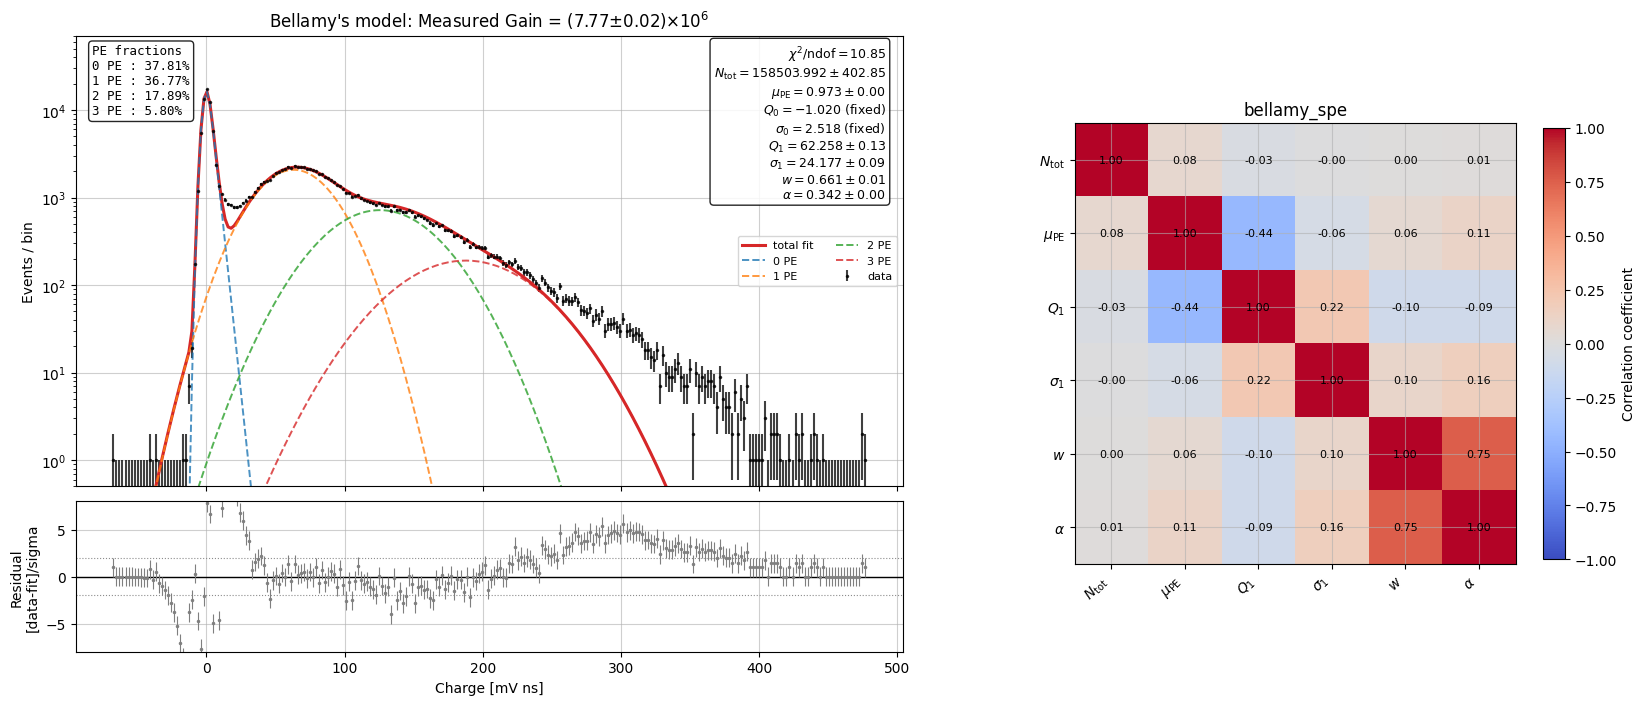

In [ ]:
maxPE = 3

p0_bellamy = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [fit_ped_expgauss['parameters']['q0_mV_ns'], -6.0, 10.0,       True],
    "sigma0_mV_ns": [fit_ped_expgauss['parameters']['sigma0_mV_ns'], 1e-4, 50.0,   True],
    "q1_mV_ns":     [30.0, 5.0, 100.0,   False],
    "sigma1_mV_ns": [11.0, 5.0, 30.0,   False],
    "mu_pe":        [0.03, 0.001, 5.0,  False],
    "w":            [0.5, 0., 1.,       False], # probability that a measured signal is accompanied by a type-2 bkg process 
    "alpha":        [fit_ped_expgauss['parameters']['alpha'], 0., 10., False], # coeff. of the exponential decay of type 2-background (positive)
}

fit_bellamy = fit_bellamy_spe(
    charge_mV_ns,
    p0=p0_bellamy,
    max_pe=maxPE,
    bins=nbins,
    fit_range=fit_range
    # fit_range=fit_range_full
)

print_fit_result_table(fit_bellamy)
print()
print(fit_bellamy["diagnostics"])

##
G , G_err = compute_gain(fit_bellamy['parameters']['q1_mV_ns'], fit_bellamy['errors']['q1_mV_ns'])
print(f"Gain is {G:.3g} +-{G_err:.2e} for Q1 = {fit_bellamy['parameters']['q1_mV_ns']}")
print( format_value(G, G_err, digits=2) )




fig, ax_fit, ax_resid, ax_corr = plot_fit_summary( fit_bellamy, title=rf"Bellamy's model: Measured Gain = ${format_value(G, G_err, digits=2)}$", 
                                                  shrink_colorbar=0.7, component_visibility_fraction=0, logscale=True, 
                                                  show_event_fractions=True, max_fraction_pe=maxPE)
save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Bellamy_{nbins}bins",  Nevents=None)

